In [1]:
# Random Forest splits data by evaluating greater-than or less-than thresholds on individual feature values

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
%matplotlib inline
# directly show the plot after the code cell, default 
warnings.filterwarnings('ignore')

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

train.shape

(891, 12)

In [4]:
test.shape

(418, 11)

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

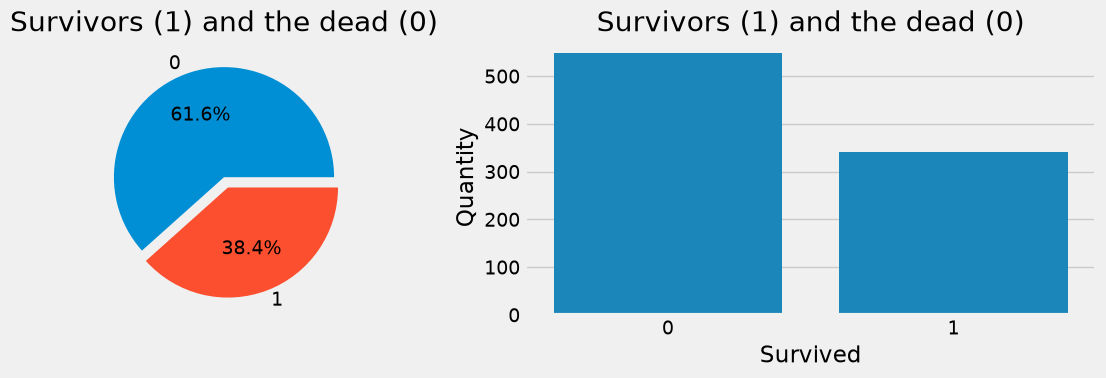

In [ ]:
f, ax = plt.subplots(1, 2, figsize=(12, 4)) 
train['Survived'].value_counts().plot.pie( 
	explode=[0, 0.1], autopct='%1.1f%%', ax=ax[0], shadow=False) 
ax[0].set_title('Survivors (1) and the dead (0)') 
ax[0].set_ylabel('') 
sns.countplot(x='Survived', data=train, ax=ax[1])
ax[1].set_ylabel('Quantity') 
ax[1].set_title('Survivors (1) and the dead (0)') 
f.tight_layout()
# squishes or expands the spacing so everything fits cleanly inside the final figure box without overlapping.
plt.show()

# This code is modified by Susobhan Akhuli

Text(0.5, 1.0, 'Survived (1) and deceased (0): men and women')

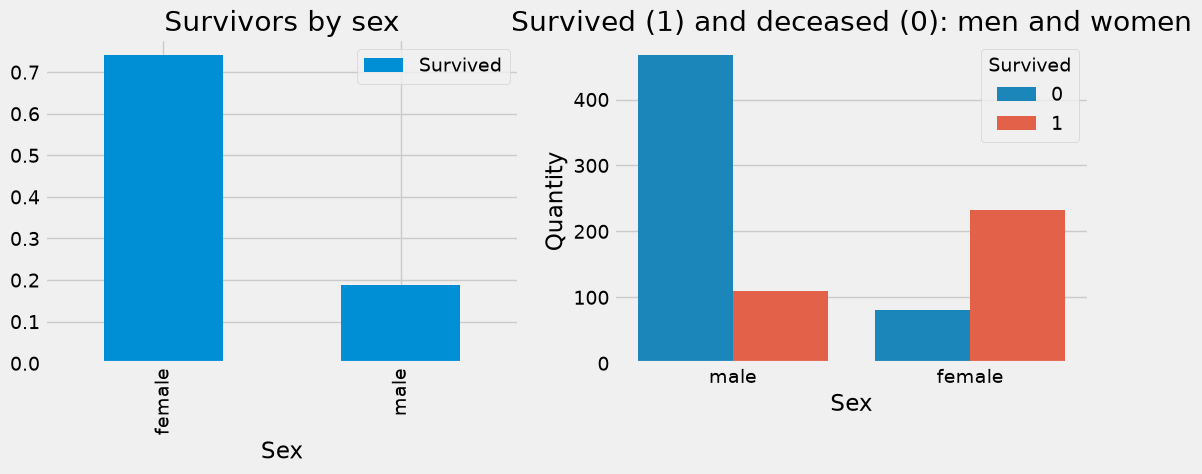

In [8]:
f,ax= plt.subplots(1,2,figsize=(12,4))
train[['Sex','Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survivors by sex')
sns.countplot(x='Sex',hue='Survived',data=train,ax=ax[1])
ax[1].set_ylabel('Quantity')
ax[1].set_title('Survived (1) and deceased (0): men and women')

In [9]:
train=train.drop(['Cabin'],axis=1)
# axis=1 drop column, axis=0 drop row 
test=test.drop(['Cabin'],axis=1)
train.shape

(891, 11)

In [10]:
train=train.drop(['Ticket'],axis=1)
test=test.drop(['Ticket'],axis=1)
test.shape

(418, 9)

In [11]:
train=train.fillna({"Embarked":"S"})

In [12]:
train["Age"] = train["Age"].fillna(-0.5)
test["Age"] = test["Age"].fillna(-0.5)
bins = [-1,0,5,12,18,24,35,60,np.inf]
# constraint: left exclude, right include: (]
labels = ['Unknown', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Senior']
train['AgeGroup']=pd.cut(train["Age"],bins,labels=labels)
test['AgeGroup']=pd.cut(test["Age"],bins,labels=labels)
# pd.cut() segment continuous numerical data into discrete categories/bins

In [13]:
combine=[train,test]
for dataset in combine:
    dataset['Title']=dataset.Name.str.extract(' ([A-Za-z]+)\.',expand=False)
    # expand=False return series instead of dataframe, create a new column named title and extract title 
pd.crosstab(train['Title'],train['Sex'])

Sex,female,male
Title,,
Capt,0,1
Col,0,2
Countess,1,0
Don,0,1
Dr,1,6
Jonkheer,0,1
Lady,1,0
Major,0,2
Master,0,40


In [14]:
for dataset in combine:
    dataset['Title'] = dataset['Title'].replace(['Capt','Col','Don','Dr','Major','Rev','Jonkheer','Dona'],'Rare')
    dataset['Title'] = dataset['Title'].replace(['Countess','Lady','Sir'],'Royal')
    dataset['Title'] = dataset['Title'].replace(['Mlle','Ms'],'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme','Mrs')
pd.crosstab(train['Title'],train['Sex'])

Sex,female,male
Title,,
Master,0,40
Miss,185,0
Mr,0,517
Mrs,126,0
Rare,1,19
Royal,2,1


Sex,female,male
Title,,
1,0,517
2,185,0
3,126,0
4,0,40
5,2,1
6,1,19


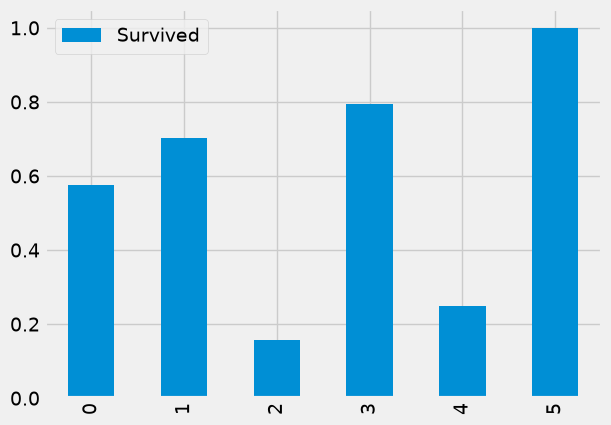

In [15]:
train[['Title','Survived']].groupby(['Title'],as_index=False).mean().plot.bar()
# not using title as index, auto-generate a new column for index 
title_mapping={"Mr":1,"Miss":2,"Mrs":3,"Master":4,"Royal":5,"Rare":6}
for dataset in combine:
    dataset['Title']=dataset['Title'].map(title_mapping)
    dataset['Title']=dataset['Title'].fillna(0)
pd.crosstab(train['Title'],train['Sex'])

In [16]:
mr_age = train[train["Title"]==1]["AgeGroup"].mode()
miss_age = train[train["Title"]==2]["AgeGroup"].mode()
mrs_age = train[train["Title"]==3]["AgeGroup"].mode()
master_age = train[train["Title"]==4]["AgeGroup"].mode()
royal_age = train[train["Title"]==5]["AgeGroup"].mode()
rare_age = train[train["Title"]==6]["AgeGroup"].mode()
# mode():find the most frequent value--> find the most frequent age for each title
print(mr_age)
# tie in mode()--> the first number represent index 
print(mr_age.iloc[0])
# pick the first when there is a tie/ iloc[-1] pick last when there is a tie

0    Young Adult
Name: AgeGroup, dtype: category
Categories (8, str): ['Unknown' < 'Baby' < 'Child' < 'Teenager' < 'Student' < 'Young Adult' < 'Adult' < 'Senior']
Young Adult


In [17]:
train.groupby('Title')['AgeGroup'].agg(
    lambda x: x.mode().iloc[0]
)
# lambda is function, mode() find the most frequent value 

Title
1    Young Adult
2        Unknown
3          Adult
4           Baby
5          Adult
6          Adult
Name: AgeGroup, dtype: category
Categories (8, str): ['Unknown' < 'Baby' < 'Child' < 'Teenager' < 'Student' < 'Young Adult' < 'Adult' < 'Senior']

In [18]:
for t in range(1,7):
    print(f"---Title {t}---")
    print(train[train["Title"]==t]["AgeGroup"].value_counts())

---Title 1---
AgeGroup
Young Adult    146
Unknown        119
Adult          111
Student         88
Teenager        34
Senior          18
Child            1
Baby             0
Name: count, dtype: int64
---Title 2---
AgeGroup
Unknown        36
Student        35
Young Adult    33
Teenager       29
Baby           21
Adult          19
Child          11
Senior          1
Name: count, dtype: int64
---Title 3---
AgeGroup
Adult          49
Young Adult    37
Unknown        17
Student        14
Teenager        7
Senior          2
Baby            0
Child           0
Name: count, dtype: int64
---Title 4---
AgeGroup
Baby           23
Child          13
Unknown         4
Teenager        0
Student         0
Young Adult     0
Adult           0
Senior          0
Name: count, dtype: int64
---Title 5---
AgeGroup
Adult          2
Young Adult    1
Unknown        0
Baby           0
Child          0
Teenager       0
Student        0
Senior         0
Name: count, dtype: int64
---Title 6---
AgeGroup
Adult       

In [19]:
# map age according to title 
age_title_mapping={1:"Young Adult", 2:"Student", 3:"Adult", 4:"Baby", 5:"Adult", 6:"Adult"}
for x in range(len(train["AgeGroup"])):
# x from 0 to 891 the length of the dataset 
    if train["AgeGroup"][x] == "Unknown":
        train["AgeGroup"][x] = age_title_mapping[train["Title"][x]]
# same as above, modern way 
mask = test["AgeGroup"] == "Unknown"
test.loc[mask, "AgeGroup"] = test.loc[mask, "Title"].map(age_title_mapping)
for t in range(1,7):
    print(f"---Title {t}---")
    print(train[train["Title"]==t]["AgeGroup"].value_counts())

---Title 1---
AgeGroup
Young Adult    146
Unknown        119
Adult          111
Student         88
Teenager        34
Senior          18
Child            1
Baby             0
Name: count, dtype: int64
---Title 2---
AgeGroup
Unknown        36
Student        35
Young Adult    33
Teenager       29
Baby           21
Adult          19
Child          11
Senior          1
Name: count, dtype: int64
---Title 3---
AgeGroup
Adult          49
Young Adult    37
Unknown        17
Student        14
Teenager        7
Senior          2
Baby            0
Child           0
Name: count, dtype: int64
---Title 4---
AgeGroup
Baby           23
Child          13
Unknown         4
Teenager        0
Student         0
Young Adult     0
Adult           0
Senior          0
Name: count, dtype: int64
---Title 5---
AgeGroup
Adult          2
Young Adult    1
Unknown        0
Baby           0
Child          0
Teenager       0
Student        0
Senior         0
Name: count, dtype: int64
---Title 6---
AgeGroup
Adult       

In [20]:
age_mapping={'Baby':1,'Child':2,'Teenager':3,'Student':4,'Young Adult':5,'Adult':6,'Senior':7}
train['AgeGroup']=train['AgeGroup'].map(age_mapping)
test['AgeGroup']=test['AgeGroup'].map(age_mapping)
train.head()
# returns top 5 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,4.0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,6.0,3
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,5.0,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,5.0,3
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,5.0,1


In [21]:
train = train.drop(['Age'],axis=1)
test = test.drop(['Age'],axis=1)
test.head()

,PassengerId,Pclass,Name,Sex,SibSp,Parch,Fare,Embarked,AgeGroup,Title
0,892,3,"Kelly, Mr. James",male,0,0,7.8292,Q,5.0,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,1,0,7.0000,S,6.0,3
2,894,2,"Myles, Mr. Thomas Francis",male,0,0,9.6875,Q,7.0,1
3,895,3,"Wirz, Mr. Albert",male,0,0,8.6625,S,5.0,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,1,1,12.2875,S,4.0,3


In [22]:
train = train.drop(['Name'],axis=1)
test = test.drop(['Name'],axis=1)

In [23]:
sex_mapping={"male":0,"female":1}
train['Sex']=train['Sex'].map(sex_mapping)
test['Sex']=test['Sex'].map(sex_mapping)
embarked_mapping={"S":1,"C":2,"Q":3}
train['Embarked']=train['Embarked'].map(embarked_mapping)
test['Embarked']=test['Embarked'].map(embarked_mapping)
train.head()

,PassengerId,Survived,Pclass,Sex,SibSp,Parch,Fare,Embarked,AgeGroup,Title
0,1,0,3,0,1,0,7.2500,1,4.0,1
1,2,1,1,1,1,0,71.2833,2,6.0,3
2,3,1,3,1,0,0,7.9250,1,5.0,2
3,4,1,1,1,1,0,53.1000,1,5.0,3
4,5,0,3,0,0,0,8.0500,1,5.0,1


In [24]:
has_nan=train['Fare'].isna().any()
print(has_nan)

False


In [25]:
nan_count=test['Fare'].isna().sum()
print(nan_count)
null_fare_indices=test[test["Fare"].isnull()].index.tolist()
print(null_fare_indices)

1
[152]


In [26]:
# fill in the empty fare by get the mean value of same pclass fare
for x in range(len(test["Fare"])):
    if pd.isnull(test["Fare"][x]):
        pclass=test["Pclass"][x]
        print(pclass)
        test["Fare"][x]=round(train[train["Pclass"]==pclass]["Fare"].mean(),4)
        print(test["Fare"][152])
        # can trigger settingwithcopywarning
        print(test.loc[x,"Fare"])
        # best way to print 
# qcut: quantile based cut: each labels have similar number of rows, each fare band has 25% of the passenger--> equal frequency
# cut: equal width
train['FareBand']=pd.qcut(train['Fare'],4,labels=[1,2,3,4])
test['FareBand']=pd.qcut(test['Fare'],4,labels=[1,2,3,4])

train=train.drop(['Fare'],axis=1)
test=test.drop(['Fare'],axis=1)

3
nan
nan


In [27]:
# algorithm: Random Forest 
from sklearn.model_selection import train_test_split
predictors= train.drop(['Survived','PassengerId'],axis=1)
target=train["Survived"]
x_train,x_val,y_train,y_val=train_test_split(predictors,target,test_size=0.2,random_state=0)
# random state: random shuffle Setting it to a fixed number--shuffle pattern (0, 42, 123, ...) makes the split reproducible — every time you run the cell, you get the same train/val split.
# test_size=0.2 same as train_size=0.8 


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

randomforest=RandomForestClassifier()
# n_estimators-number of trees, max_depth-depth of tree, min_sample_split-min sample requires to split a node, random_state-shuffle pattern
# default: n_estimator 100
randomforest.fit(x_train,y_train)
# learn
y_pred=randomforest.predict(x_val)
# predict 
acc_randomforest=round(accuracy_score(y_val,y_pred)*100,2)
# accuracy_score: calculate the correct predictions out of all predictions
# round return float, the trailing 0 is omitted 
print(f"{acc_randomforest:.2f}")
# display with 2 decimal 

84.36


In [29]:
importances=randomforest.feature_importances_
feat_imp=pd.Series(importances, index=x_train.columns).sort_values(ascending=False)
print(feat_imp)

Title       0.239484
Sex         0.179407
AgeGroup    0.159651
Pclass      0.122939
FareBand    0.099163
SibSp       0.086247
Parch       0.057882
Embarked    0.055227
dtype: float64


Text(0.5, 0, 'Importance score')

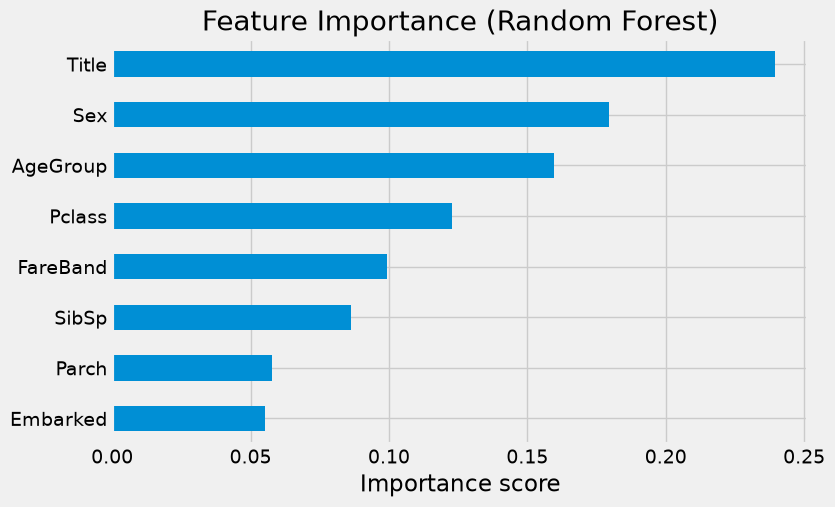

In [30]:
feat_imp.sort_values().plot.barh(figsize=(8,5))
# horizontal bar chart
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance score")

Text(0, 0.5, '')

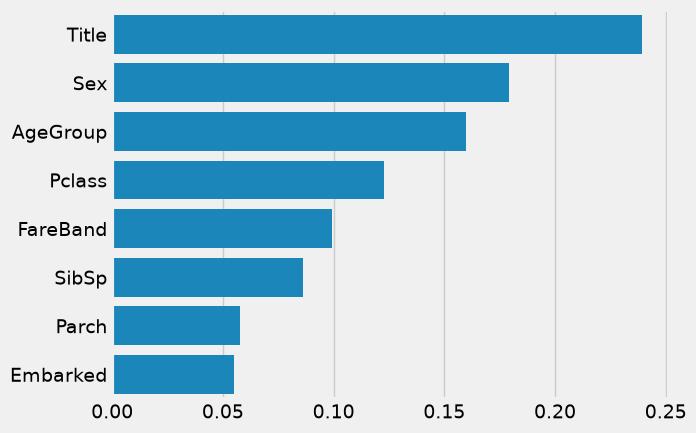

In [31]:
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.ylabel("")

In [32]:
from sklearn.inspection import permutation_importance
# permutation_importance: how much performance lost when destroy a feature; bigger drop->more important feature->higher dependency; negative means noise
# Measures accuracy drop when a feature is shuffled. Bigger drop = more important. n_repeats=10 averages 10 shuffles.
result=permutation_importance(randomforest,x_val,y_val,n_repeats=10,random_state=0)
perm_imp=pd.Series(result.importances_mean, index=x_train.columns).sort_values(ascending=False)
print(perm_imp)

Pclass      0.118436
Sex         0.068156
Title       0.063128
FareBand    0.037430
AgeGroup    0.034637
SibSp       0.025140
Embarked    0.008380
Parch      -0.006145
dtype: float64


In [33]:
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score, confusion_matrix, classification_report
# TP/TN: correct detection FP:false alarm FN:missed detection
print("Accuracy:", accuracy_score(y_val,y_pred))
# Accuracy: (TP+TN)/(TP+TN+FP+FN) : use when class are balanced
print("Precision:", precision_score(y_val,y_pred))
# Precision: TP/(TP+FP) : high precision: few false alarm 
print("Recall:", recall_score(y_val,y_pred))
# Recall=TP/(TP+FN): high recall: few missed postive 
print("F1:", f1_score(y_val,y_pred))
# F1 = 2 × (Precision × Recall) / (Precision + Recall) : use when class are imbalanced
print(classification_report(y_val,y_pred))
# support: number of samples
# macro avg: unweighted mean of all per-class scores
# weighted avg:multiplies each class's metric by its support (number of samples), sums them up, and divides by the total number of samples across all classes.

Accuracy: 0.8435754189944135
Precision: 0.8153846153846154
Recall: 0.7681159420289855
F1: 0.7910447761194029
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       110
           1       0.82      0.77      0.79        69

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



Text(0.5, 1.0, 'Confusion Matrix')

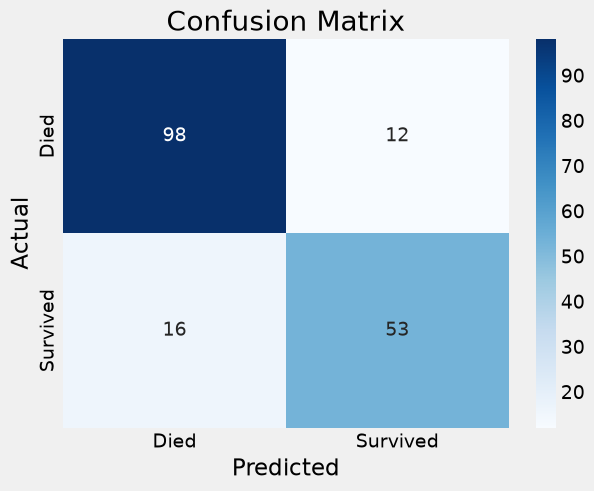

In [34]:
cm=confusion_matrix(y_val,y_pred)
#                 Predicted 0   Predicted 1
# Actual 0            TN            FP
# Actual 1            FN            TP
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Died','Survived'],yticklabels=['Died','Survived'])
# Annotate each cell with its value (write the number inside the box)
# Format the annotation as an integer (d = decimal integer, .2f = float with 2 decimal, .1% = percentage, .2g = 2 significant digit 
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

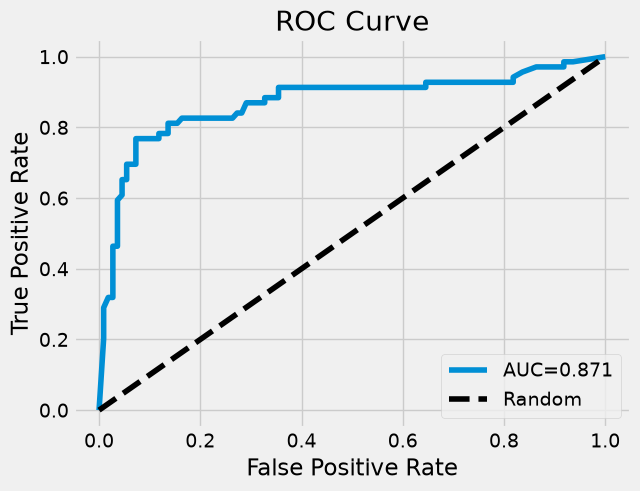

In [35]:
from sklearn.metrics import roc_curve, roc_auc_score
# roc: receiver operating characteristic 
y_prob=randomforest.predict_proba(x_val)[:,1]
# returns probabilities shape:(n_rows,2)-->column0: probability of died(0), column1: probability of survived(1)
# [:,1]: select column 1(survived column)
fpr,tpr,_=roc_curve(y_val,y_prob)
# fpr:false positive rate, tpr:true positive rate, _:threshold placeholder, not save
auc=roc_auc_score(y_val,y_prob)
# area under curve:The model with greater area under the curve is generally the better one.
plt.plot(fpr,tpr,label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'k--',label="Random")
# diagonal dashed line from (0,0) to (1,1), 'k--':black dashed --->50% random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
# The curve rises steeply near the left. This means: at low false-positive rates, the model already catches many true positives 
# At FPR ≈ 0.1, TPR ≈ 0.8 — so with only 10% false positives, the model catches 80% of survivors. Very good.
# The curve is far above the diagonal — the model is far better than random.

In [36]:
ids=test['PassengerId']
predictions=randomforest.predict(test.drop("PassengerId",axis=1))
output=pd.DataFrame({'PassengerId':ids,'Survived':predictions})
output.to_csv('resultfile.csv',index=False)